In [41]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
import sys
from pathlib import Path

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.append(str(root / "src"))

In [43]:
import torch
import matplotlib.pyplot as plt

In [44]:
d = 8
pos = 5

i = torch.arange(d // 2)           # pair index: 0, 1, 2, 3
freq = 1.0 / 10000 ** (2 * i / d)  # one frequency per pair
angle = pos * freq                 # [d/2]

pe = torch.zeros(d)
pe[0::2] = torch.sin(angle)
pe[1::2] = torch.cos(angle)
pe


tensor([-0.9589,  0.2837,  0.4794,  0.8776,  0.0500,  0.9988,  0.0050,  1.0000])

In [45]:
freq, 2 * torch.pi / freq  # frequency, and wavelength (positions per full cycle)


(tensor([1.0000, 0.1000, 0.0100, 0.0010]),
 tensor([   6.2832,   62.8319,  628.3185, 6283.1851]))

In [46]:
for n in range(8):
    print(f"{n:04b}")


0000
0001
0010
0011
0100
0101
0110
0111


In [47]:
d = 64
max_len = 128

pos = torch.arange(max_len).unsqueeze(1)  # [T, 1]
i = torch.arange(d // 2)
freq = 1.0 / 10000 ** (2 * i / d)         # [d/2]
angle = pos * freq                        # [T, 1] * [d/2] -> [T, d/2]

pe = torch.zeros(max_len, d)
pe[:, 0::2] = torch.sin(angle)
pe[:, 1::2] = torch.cos(angle)
pe.shape


torch.Size([128, 64])

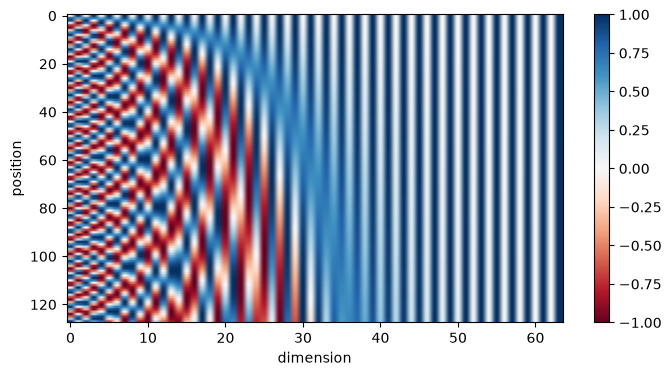

In [48]:
plt.figure(figsize=(8, 4))
plt.imshow(pe, aspect="auto", cmap="RdBu")
plt.xlabel("dimension")
plt.ylabel("position")
plt.colorbar()


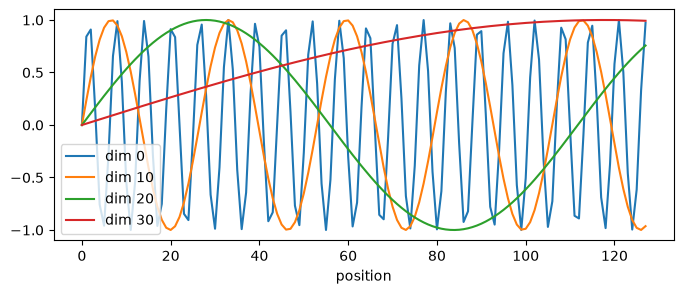

In [49]:
plt.figure(figsize=(8, 3))
for dim in [0, 10, 20, 30]:
    plt.plot(pe[:, dim], label=f"dim {dim}")
plt.xlabel("position")
plt.legend()


In [50]:
def build_pe(max_len, d, base=10000.0):
    pos = torch.arange(max_len).unsqueeze(1).float()   # [T, 1]
    i = torch.arange(d // 2)
    freq = 1.0 / base ** (2 * i / d)                   # [d/2]
    angle = pos * freq                                 # [T, d/2]
    pe = torch.zeros(max_len, d)
    pe[:, 0::2] = torch.sin(angle)
    pe[:, 1::2] = torch.cos(angle)
    return pe, freq

pe, freq = build_pe(512, 64)
pe.shape


torch.Size([512, 64])

In [51]:
d = 64
pos, k = 5, 3

s, c = pe[pos, 0::2], pe[pos, 1::2]     # the pair components at pos
ck, sk = torch.cos(k * freq), torch.sin(k * freq)   # depends on k only

rotated = torch.zeros(d)
rotated[0::2] = s * ck + c * sk
rotated[1::2] = c * ck - s * sk

(rotated - pe[pos + k]).abs().max()     # ~1e-7


tensor(1.1921e-07)

In [52]:
G = pe @ pe.T                     # [T, T] all pairwise dot products
G[10, 13], G[50, 53], G[100, 103]


(tensor(25.5870), tensor(25.5870), tensor(25.5870))

In [53]:
torch.cos(3 * freq).sum()         # same number


tensor(25.5870)

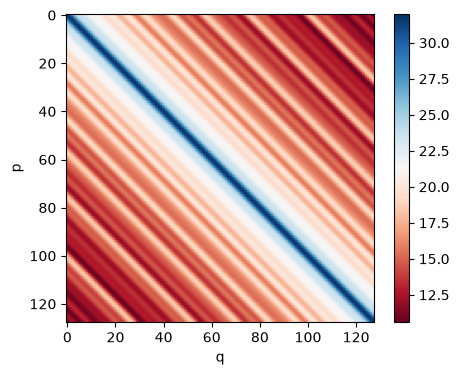

In [54]:
plt.figure(figsize=(5, 4))
plt.imshow(G[:128, :128], cmap="RdBu")
plt.xlabel("q"); plt.ylabel("p"); plt.colorbar()


In [55]:
pe_long, _ = build_pe(2048, 64)
G_long = pe_long @ pe_long.T
G_long[10, 20], G_long[400, 410], G_long[1500, 1510]


(tensor(21.0516), tensor(21.0516), tensor(21.0516))

In [56]:
torch.manual_seed(0)
A = torch.randn(64, 64) / 64 ** 0.5      # stand-in for Wq @ Wk.T

GA = pe @ A @ pe.T
GA[10, 13], GA[50, 53], GA[100, 103]     # no longer equal


(tensor(0.4271), tensor(-0.6264), tensor(-0.9947))

In [57]:
gap3 = torch.stack([G[p, p + 3] for p in range(120)])
gap3_A = torch.stack([GA[p, p + 3] for p in range(120)])

print("plain dot,  gap=3:", gap3.mean().item(), "±", gap3.std().item())
print("through A,  gap=3:", gap3_A.mean().item(), "±", gap3_A.std().item(), "| overall spread", GA.std().item())


plain dot,  gap=3: 25.58702850341797 ± 4.029061074106721e-06
through A,  gap=3: -0.0198252834379673 ± 4.158930778503418 | overall spread 3.642319917678833


In [58]:
[(o, round(G[200, 200 + o].item(), 2)) for o in [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]]


[(0, 32.0),
 (1, 30.92),
 (2, 28.3),
 (4, 23.93),
 (8, 22.41),
 (16, 19.37),
 (32, 19.55),
 (64, 13.91),
 (128, 9.08),
 (256, 11.32)]

In [59]:
# 1. pe is ADDED to x, so position and content share the same vector space.
#    They interfere, and Wq/Wk see a mixture, not two clean signals.
# 2. The relative-position identity holds only for a bare dot product,
#    which is not what attention computes (cell 13).
